In [1]:
import veloxchem as vlx

In [2]:
mn_bpy = """
Mn         9.41590       20.57460        4.21800
O          7.08510       18.77380        3.92540
O          9.24320       20.22830        7.15190
O         11.47850       18.54920        3.74800
N          9.07170       21.42610        2.46140
N         10.46550       22.24920        4.40520
C         10.65480       19.36280        3.92850
C          8.01260       19.48050        4.04710
C          9.31010       20.35620        5.98820
C         11.21370       22.62830        5.48660
C         11.97740       23.76570        5.54380
H         12.53230       23.99480        6.44870
C         12.02470       24.62600        4.40860
H         12.62260       25.53350        4.41880
C         11.29940       24.27080        3.29970
H         11.31740       24.89670        2.41230
C         10.51770       23.08570        3.28770
C          9.73880       22.62770        2.20280
C          9.60920       23.28140        0.94970
C          8.82480       22.75340       -0.04410
C          8.15270       21.52390        0.21760
C          8.31050       20.92310        1.43940
H         11.16360       21.95400        6.33380
H         10.14400       24.21260        0.78630
H          8.72350       23.25410       -1.00340
H          7.51890       21.05760       -0.53100
H          7.81270       19.98620        1.66040

"""

In [3]:
molecule = vlx.Molecule.read_str(mn_bpy)
molecule.set_charge(-1)
basis = vlx.MolecularBasis.read(molecule, 'def2-svpd')
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = 'cam-b3lyp'
results = scf_drv.compute(molecule, basis)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [4]:
rpa_solver = vlx.LinearResponseEigenSolver()
rpa_solver.nstates = 4
rpa_results = rpa_solver.compute(molecule, basis, results)

                                                                                                                          
                                            Linear Response EigenSolver Setup                                             
                                                                                                                          
                               Number of States                : 4                                                        
                               Max. Number of Iterations       : 150                                                      
                               Convergence Threshold           : 1.0e-04                                                  
                               ERI Screening Threshold         : 1.0e-12                                                  
                               Exchange-Correlation Functional : CAM-B3LYP                                                
                

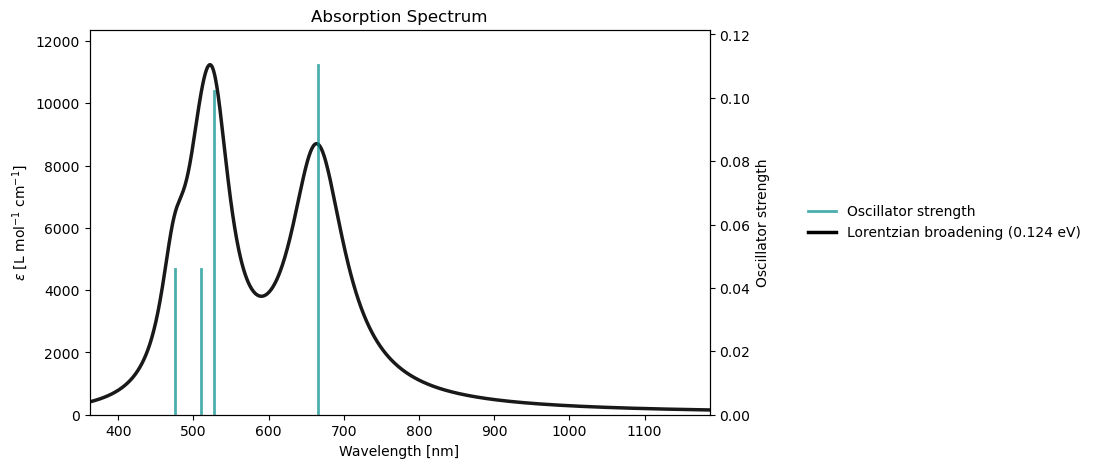

In [5]:
rpa_solver.plot_uv_vis(rpa_results)

In [6]:
xyz_files = ["Mn_bpy", "Mn_bpyPh2"]  
for xyz_file in xyz_files:
    molecule = vlx.Molecule.read_xyz_file(xyz_file + ".xyz")
    molecule.set_charge(-1)
    basis = vlx.MolecularBasis.read(molecule, 'def2-svpd')
    scf_drv = vlx.ScfRestrictedDriver()
    scf_drv.xcfun = 'cam-b3lyp'
    scf_drv.filename = f"sp_results_{xyz_file}"
    results = scf_drv.compute(molecule, basis)
    rpa_solver = vlx.LinearResponseEigenSolver()
    rpa_solver.nstates = 6
    rpa_results = rpa_solver.compute(molecule, basis, results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [27]:
rpa_results.keys()

dict_keys(['eigenvalues', 'eigenvectors_distributed', 'electric_transition_dipoles', 'velocity_transition_dipoles', 'magnetic_transition_dipoles', 'oscillator_strengths', 'rotatory_strengths', 'excitation_details', 'number_of_states'])

In [7]:
import h5py
filename = "sp_results_Mn_bpy.h5"

with h5py.File(filename, "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    # get first object name/key; may or may NOT be a group
    a_group_key = list(f.keys())[0]

    # get the object type for a_group_key: usually group or dataset
    print(type(f[a_group_key])) 

    # If a_group_key is a group name, 
    # this gets the object names in the group and returns as a list
    data = list(f[a_group_key])

    # If a_group_key is a dataset name, 
    # this gets the dataset values and returns as a list
    data = list(f[a_group_key])
    # preferred methods to get dataset values:
    ds_obj = f[a_group_key]      # returns as a h5py dataset object
    ds_arr = f[a_group_key][()]  # returns as a numpy array

Keys: <KeysViewHDF5 ['atom_coordinates', 'basis_set', 'dft_func_label', 'molecular_charge', 'nuclear_charges', 'nuclear_repulsion', 'number_of_alpha_electrons', 'number_of_atoms', 'number_of_beta_electrons', 'potfile_text', 'rsp', 'scf', 'spin_multiplicity']>
<class 'h5py._hl.dataset.Dataset'>


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

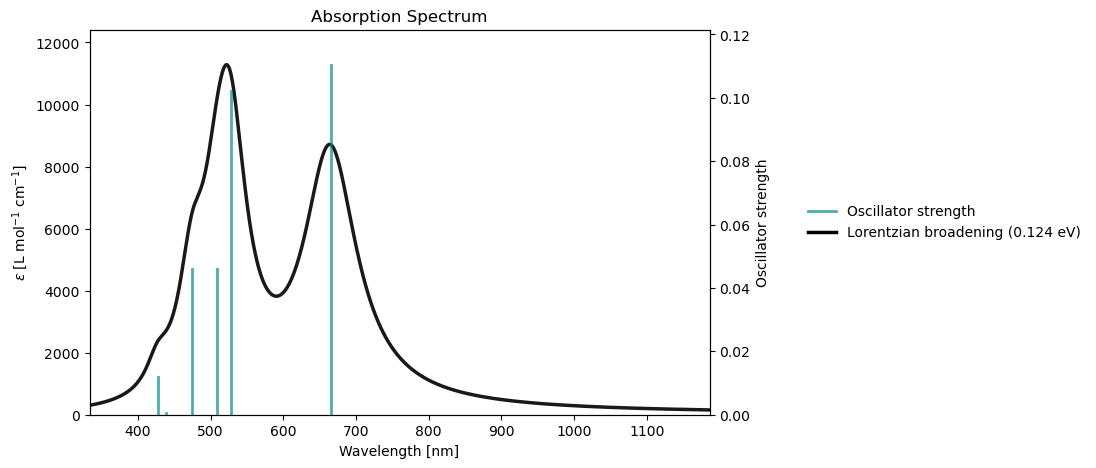

In [25]:
mol = vlx.Molecule.read_xyz_file('Mn_bpy.xyz')
mol.show()
rpa_results_saved = vlx.read_results("sp_results_Mn_bpy.h5", label="rsp")
rpa_solver.plot_uv_vis(rpa_results_saved)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

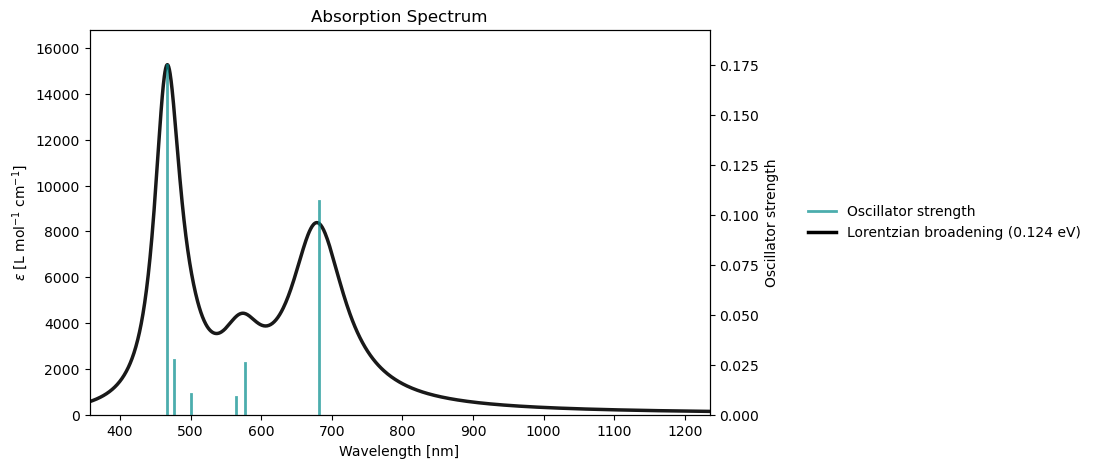

In [26]:
mol = vlx.Molecule.read_xyz_file('Mn_bpyPh2.xyz')
mol.show()
rpa_results_saved = vlx.read_results("sp_results_Mn_bpyPh2.h5", label="rsp")
rpa_solver.plot_uv_vis(rpa_results_saved)